# Header-based Translation Status

Analyze translation status by comparing the number of markdown headers (# ## ### etc.) between English and translated documents.

In [ ]:
import json
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

repo_path = Path("../k8s-repo/website")
translation_status_path = Path("../data/output/translation_status.json")

with open(translation_status_path, 'r', encoding='utf-8') as f:
    translation_data = json.load(f)

In [2]:
def count_headers(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        
        headers = {'h1': 0, 'h2': 0, 'h3': 0, 'h4': 0, 'h5': 0, 'h6': 0, 'total': 0}
        in_front_matter = False
        in_comment = False
        front_matter_count = 0
        header_pattern = re.compile(r'^(#{1,6})\s+.+')
        
        for line in lines:
            stripped = line.strip()
            
            if stripped == '---':
                front_matter_count += 1
                if front_matter_count == 1:
                    in_front_matter = True
                    continue
                elif front_matter_count == 2:
                    in_front_matter = False
                    continue
            
            if in_front_matter:
                continue
            
            if '<!--' in stripped:
                in_comment = True
                if '-->' in stripped:
                    in_comment = False
                continue
            
            if in_comment:
                if '-->' in stripped:
                    in_comment = False
                continue
            
            match = header_pattern.match(stripped)
            if match:
                header_level = len(match.group(1))
                headers[f'h{header_level}'] += 1
                headers['total'] += 1
        
        return headers
    except Exception as e:
        return None

In [ ]:
all_header_data = []

for path, data in translation_data.items():
    lang = data.get('language')
    if lang == 'en':
        continue
    
    en_path = repo_path / data.get('english_path', '')
    trans_path = repo_path / path
    
    if en_path.exists() and trans_path.exists():
        en_headers = count_headers(en_path)
        trans_headers = count_headers(trans_path)
        
        if en_headers and trans_headers:
            all_header_data.append({
                'language': lang,
                'path': path,
                'status': data['history']['status'],
                'en_headers': en_headers['total'],
                'trans_headers': trans_headers['total'],
                'header_match': en_headers['total'] == trans_headers['total'],
                'header_diff': trans_headers['total'] - en_headers['total']
            })

lang_counts = {item['language']: lang_counts.get(item['language'], 0) + 1 
               for item in all_header_data}
major_langs = sorted([lang for lang, count in lang_counts.items() if count >= 20])

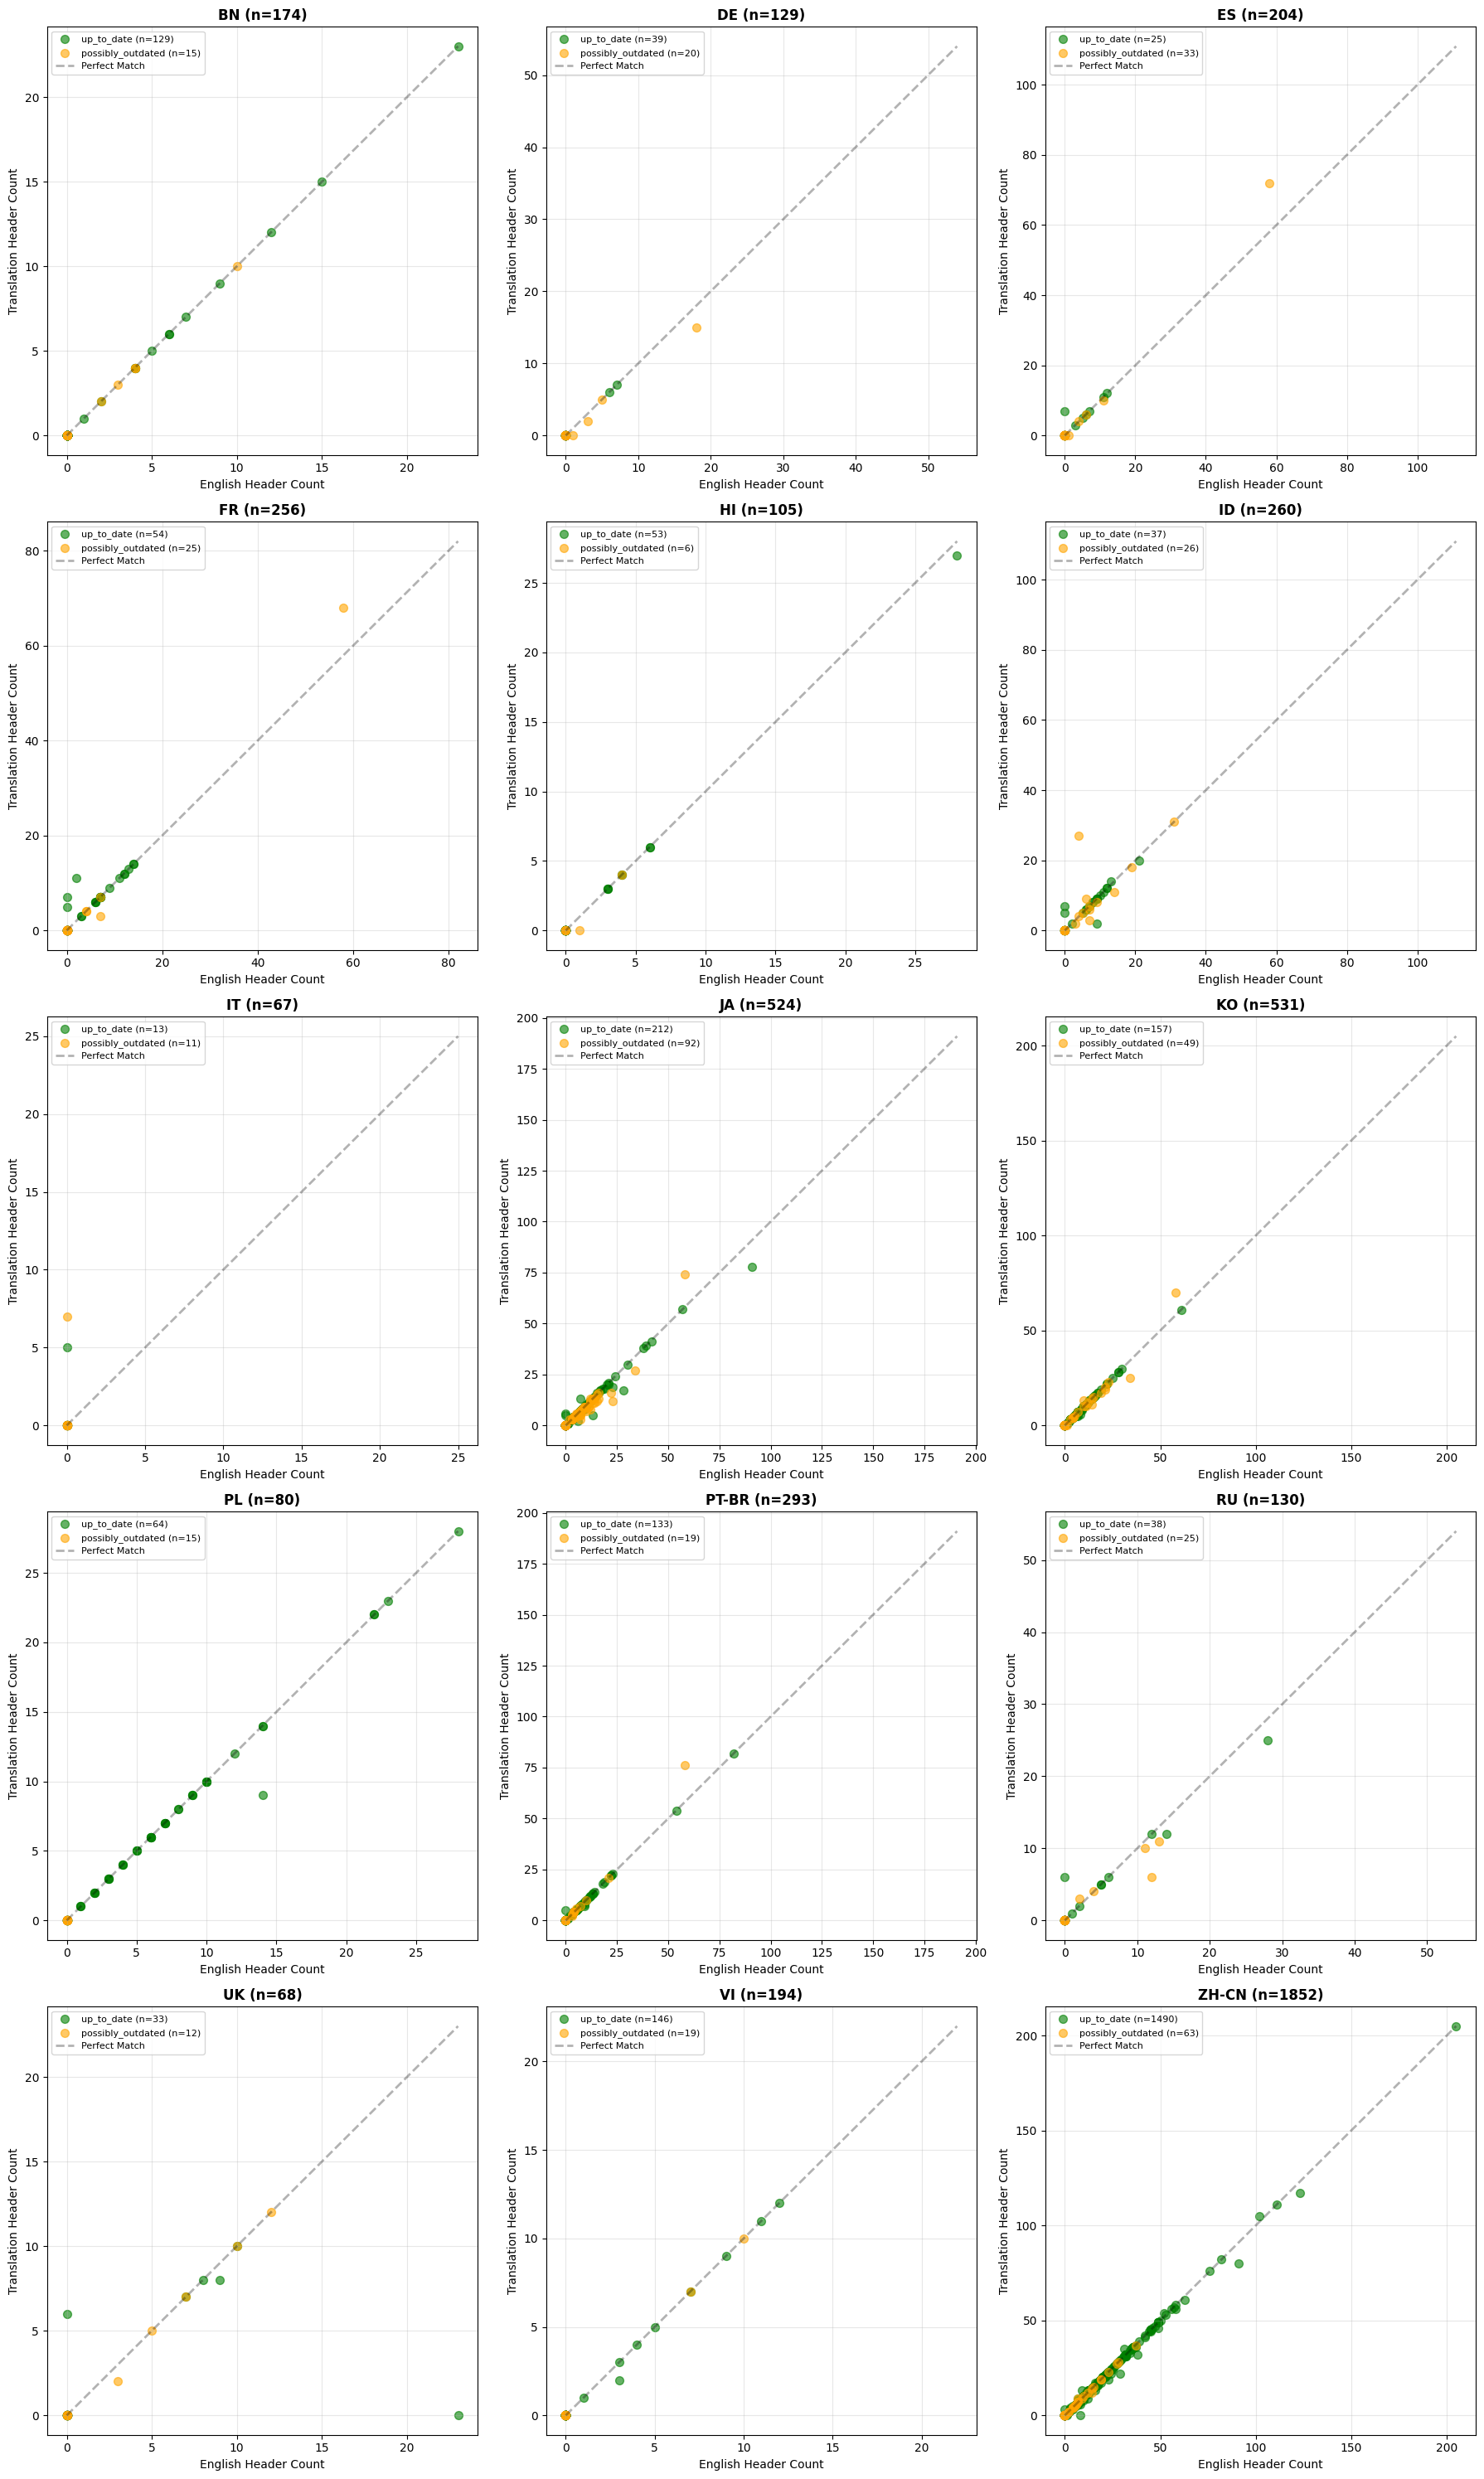

In [ ]:
n_langs = len(major_langs)
n_cols = 3
n_rows = (n_langs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten() if n_langs > 1 else [axes]

status_colors = {'up_to_date': 'green', 'possibly_outdated': 'orange', 'outdated': 'red'}

for idx, lang in enumerate(major_langs):
    ax = axes[idx]
    lang_data = [item for item in all_header_data if item['language'] == lang]
    
    for status in ['up_to_date', 'possibly_outdated']:
        status_data = [item for item in lang_data if item['status'] == status]
        if status_data:
            en_headers = [item['en_headers'] for item in status_data]
            trans_headers = [item['trans_headers'] for item in status_data]
            ax.scatter(en_headers, trans_headers, alpha=0.6, s=50,
                      c=status_colors.get(status, 'blue'),
                      label=f'{status} (n={len(status_data)})')
    
    max_headers = max(max([item['en_headers'] for item in lang_data]),
                     max([item['trans_headers'] for item in lang_data]))
    ax.plot([0, max_headers], [0, max_headers], 'k--', alpha=0.3, linewidth=2, label='Perfect Match')
    
    ax.set_xlabel('English Header Count', fontsize=10)
    ax.set_ylabel('Translation Header Count', fontsize=10)
    ax.set_title(f'{lang.upper()} (n={len(lang_data)})', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

for idx in range(n_langs, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

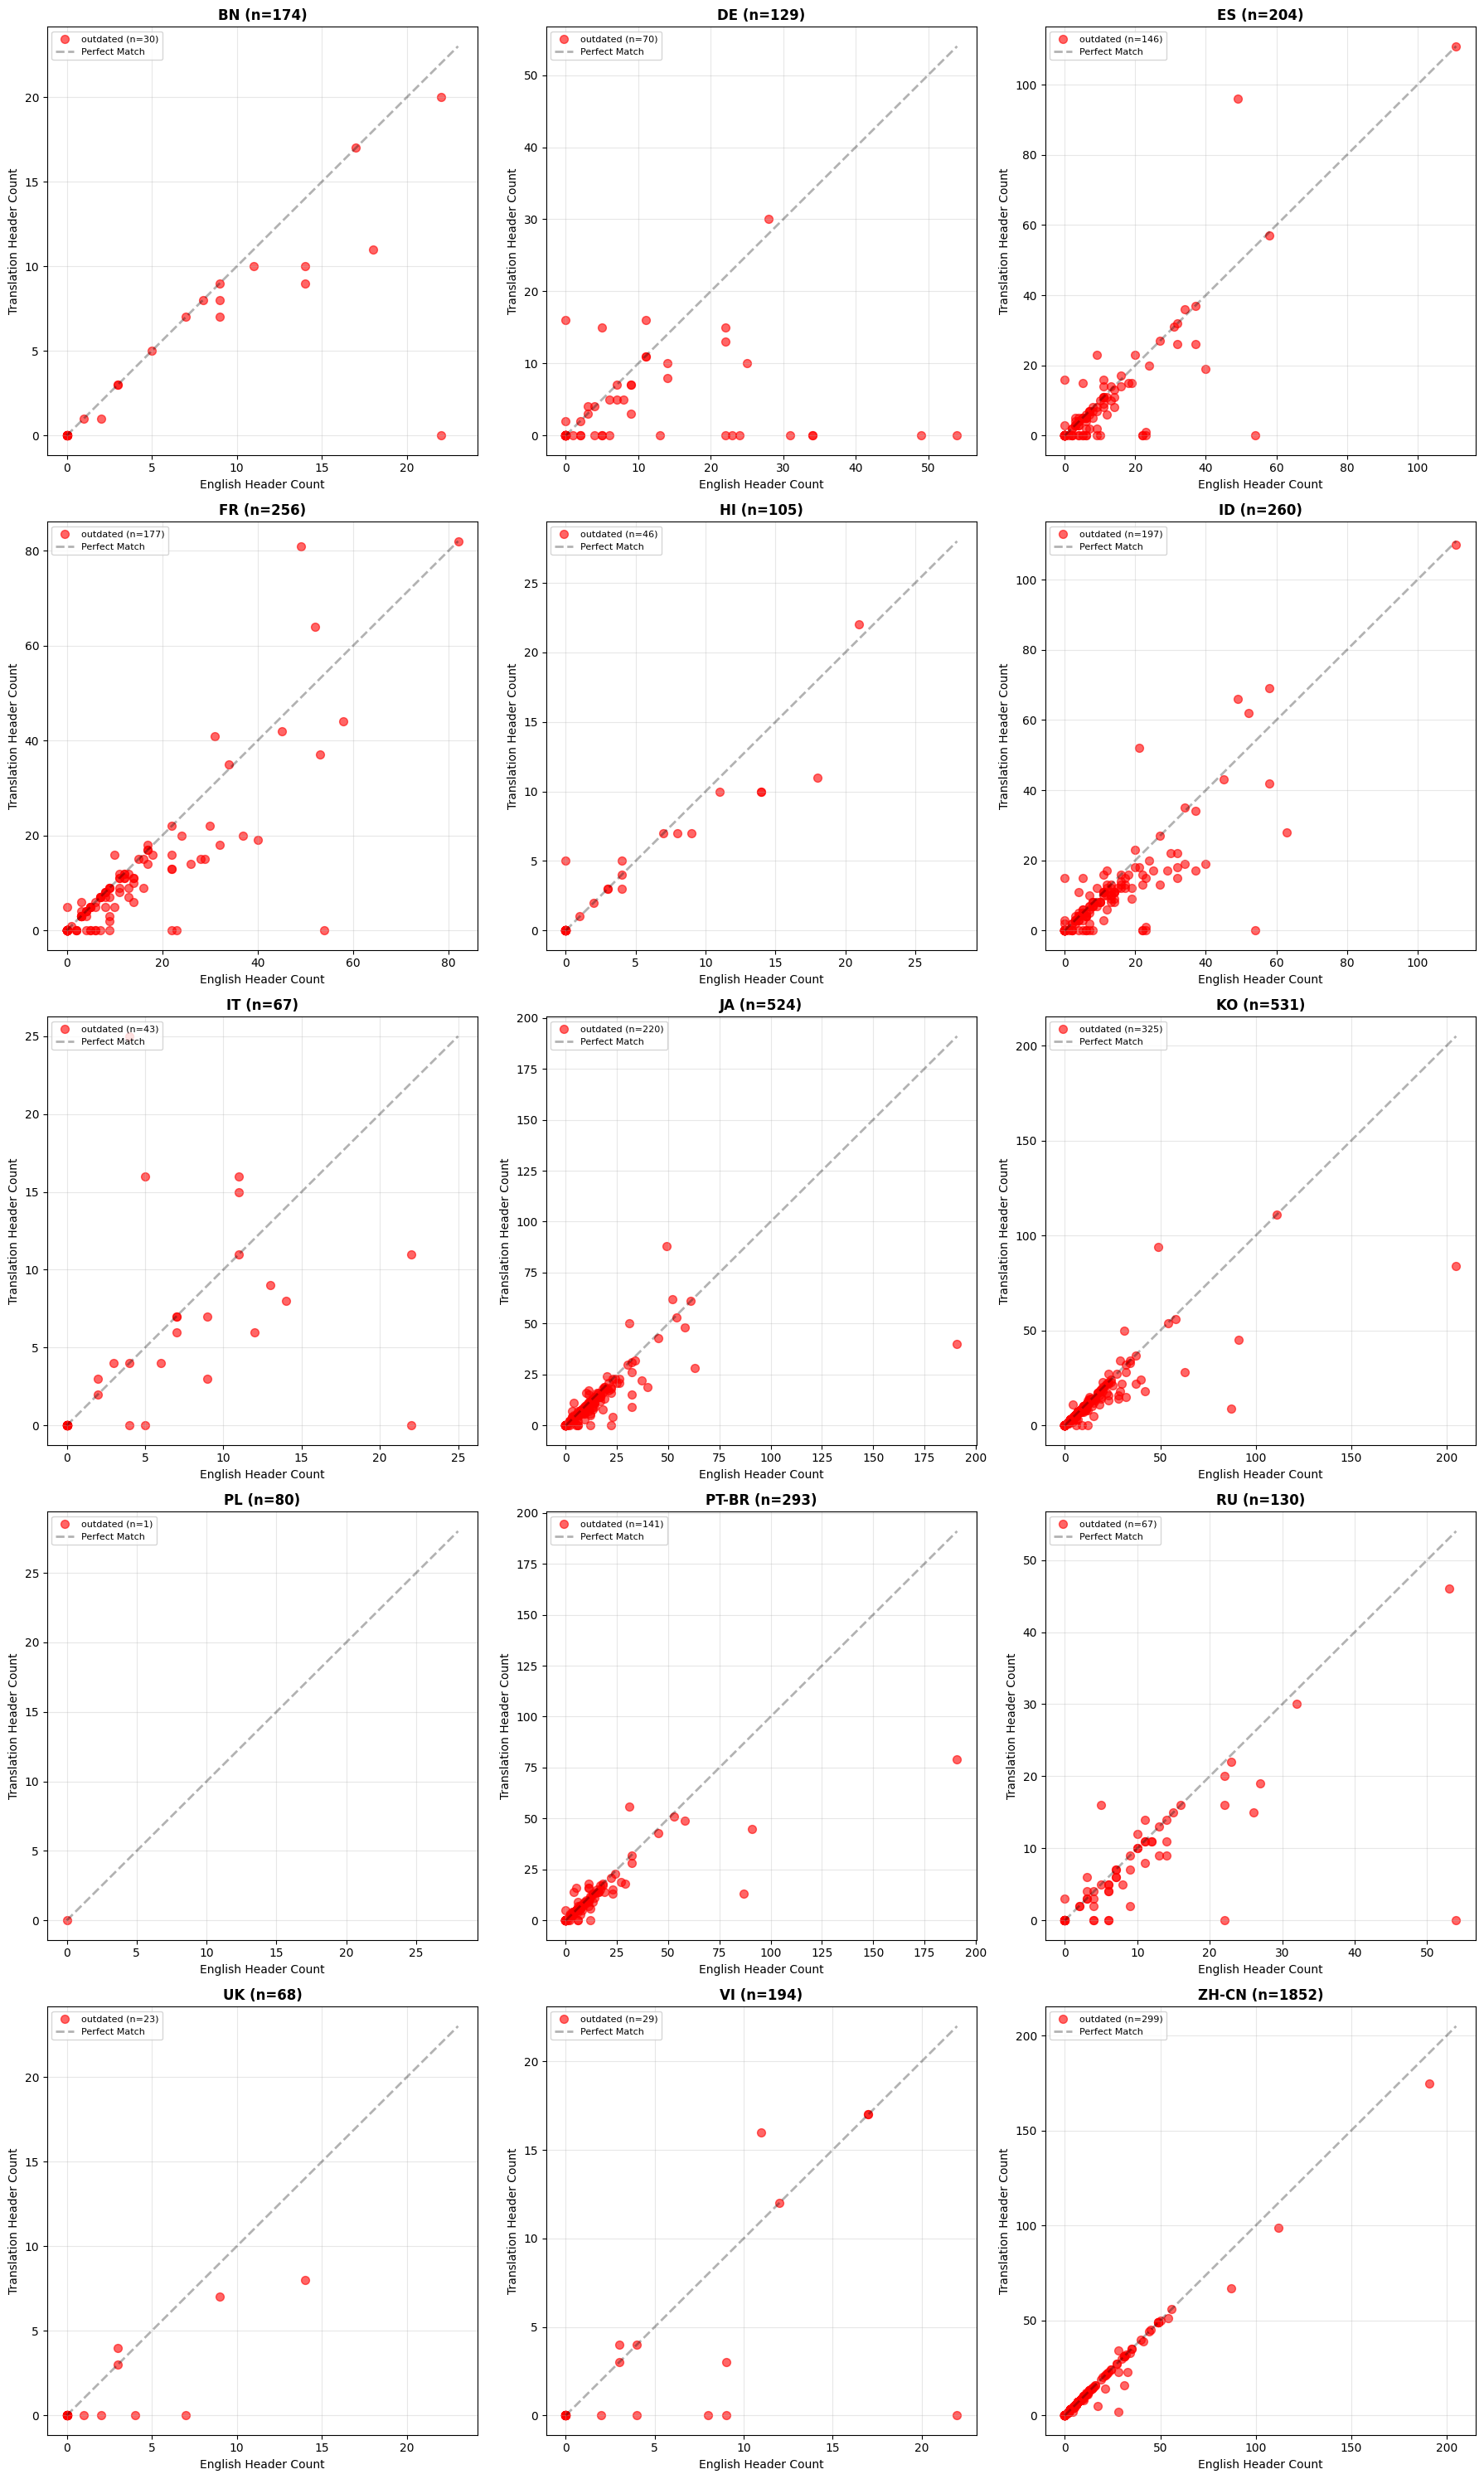

In [ ]:
n_langs = len(major_langs)
n_cols = 3
n_rows = (n_langs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten() if n_langs > 1 else [axes]

status_colors = {'up_to_date': 'green', 'possibly_outdated': 'orange', 'outdated': 'red'}

for idx, lang in enumerate(major_langs):
    ax = axes[idx]
    lang_data = [item for item in all_header_data if item['language'] == lang]
    
    status_data = [item for item in lang_data if item['status'] == 'outdated']
    if status_data:
        en_headers = [item['en_headers'] for item in status_data]
        trans_headers = [item['trans_headers'] for item in status_data]
        ax.scatter(en_headers, trans_headers, alpha=0.6, s=50,
                  c=status_colors.get('outdated', 'blue'),
                  label=f'outdated (n={len(status_data)})')
    
    max_headers = max(max([item['en_headers'] for item in lang_data]),
                     max([item['trans_headers'] for item in lang_data]))
    ax.plot([0, max_headers], [0, max_headers], 'k--', alpha=0.3, linewidth=2, label='Perfect Match')
    
    ax.set_xlabel('English Header Count', fontsize=10)
    ax.set_ylabel('Translation Header Count', fontsize=10)
    ax.set_title(f'{lang.upper()} (n={len(lang_data)})', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

for idx in range(n_langs, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()